In [26]:
import importlib
import sys
from pathlib import Path
import pandas as pd

root = Path.cwd().parent.parent
sys.path.insert(0, str(root / "code"))

data_path = root / "data"

out_path = root / "out"

import plot.plots as plots
import mining.candidate_mining as mining
import mining.symbolic_features as symbolic_features
import experiments.experiment as experiments
import mining.token_counting as counting
import mining.alert_tokenization as alert_tokenization

importlib.reload(plots)
importlib.reload(mining)
importlib.reload(symbolic_features)
importlib.reload(experiments)
importlib.reload(counting)
importlib.reload(alert_tokenization)


from plot.plots import *
from mining.candidate_mining import *
from mining.symbolic_features import build_symbolic_features_from_candidates_cached
from experiments.experiment import simple_ablation_experiment_p
from mining.token_counting import count_itemsets_eclat, count_itemsets_matmul
from mining.alert_tokenization import build_token_cache_for_scenario, save_token_cache

### Load labeled dataset

In [ ]:
df = pd.read_csv(os.path.join(data_path, "ait_ads/labeled_combined_ait.csv"), low_memory=False)

In [28]:
# make sure timestamps are datetime and sorted
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
df = df.dropna(subset=["timestamp"]).sort_values("timestamp")

##### Normalize `category`

In [32]:
df["category_norm"] = df["category"].astype(str).str.split(" - ").str[0].str.strip()

#### Set parameters

In [72]:
run_name="eclat-mining-test"
output_dir = os.path.join(out_path, run_name)

os.makedirs(output_dir,exist_ok=True)
min_support=10

scorer_name = "split_bayes"
miner_name = "2-itemset"
scenario_name = "harrison"

In [73]:
dup_counts = df[df["scenario"] == scenario_name].groupby("alert_id").size()
print(dup_counts.describe())
print((dup_counts > 1).sum(), "alert_ids occur more than once")

count    136858.000000
mean          1.001242
std           0.066969
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          10.000000
dtype: float64
82 alert_ids occur more than once


### Tokenize alerts

In [74]:
meta_df, X_tokens_all, vocab = build_token_cache_for_scenario(
    df=df,
    scenario_name=scenario_name
)

save_token_cache(
    meta_df=meta_df,
    X_tokens_all=X_tokens_all,
    vocab=vocab,
    scenario_name=scenario_name,
    run_name=run_name,
)

Building token cache for scenario: harrison
Tokenizing using 34 fields (out of 35 requested). 
Excluded fields: {'srcport'}
Token cache built: 137028 row-alerts, 6166 unique tokens
Saving token cache for scenario 'harrison' to disk...
Token cache saved to: /Users/annavisman/stack/TUDelft/thesis/msc-thesis/out/eclat-mining-test/tokens/harrison


### Window based mining run (scenario local)

##### 1) Token counting

In [75]:
scenario_counts, scenario_attack_flags = window_based_mining(
    scenario_name=scenario_name,
    run_name=run_name,
    counter=count_itemsets_eclat,
    counter_kwargs={
        "k": 2,
        "min_support": 10,
    },
)

Running mining for precached scenario 'harrison'...
Iterating precached windows for scenario 'harrison'...
Loading token cache for scenario 'harrison' from disk...
Token cache loaded: 137028 alerts, 6166 unique tokens
Slicing token cache by time: 2022-02-04 00:00:00+00:00 to 2022-02-04 12:00:00+00:00 (include_end=False)
Sliced window: 15381 alerts
Processing window 2022-02-04 00:00:00+00:00 to 2022-02-04 12:00:00+00:00...


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/code/util.py:115: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  win = pd.Timedelta(window_size)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/code/util.py:116: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  step = pd.Timedelta(step_size)


[harrison] 2022-02-04 00:00:00+00:00 -> 2022-02-04 12:00:00+00:00 | n=15381 | benign=15381 | attack=0
Slicing token cache by time: 2022-02-04 12:00:00+00:00 to 2022-02-05 00:00:00+00:00 (include_end=False)
Sliced window: 17623 alerts
Processing window 2022-02-04 12:00:00+00:00 to 2022-02-05 00:00:00+00:00...
[harrison] 2022-02-04 12:00:00+00:00 -> 2022-02-05 00:00:00+00:00 | n=17623 | benign=17623 | attack=0
Slicing token cache by time: 2022-02-05 00:00:00+00:00 to 2022-02-05 12:00:00+00:00 (include_end=False)
Sliced window: 13133 alerts
Processing window 2022-02-05 00:00:00+00:00 to 2022-02-05 12:00:00+00:00...
[harrison] 2022-02-05 00:00:00+00:00 -> 2022-02-05 12:00:00+00:00 | n=13133 | benign=13133 | attack=0
Slicing token cache by time: 2022-02-05 12:00:00+00:00 to 2022-02-06 00:00:00+00:00 (include_end=False)
Sliced window: 15026 alerts
Processing window 2022-02-05 12:00:00+00:00 to 2022-02-06 00:00:00+00:00...
[harrison] 2022-02-05 12:00:00+00:00 -> 2022-02-06 00:00:00+00:00 | n=

Save token counts to csv

In [76]:
os.makedirs(f"{output_dir}/csv/{scenario_name}", exist_ok=True)

scen = scenario_counts.get(scenario_name, [])

for i, (df_scen, n0, n1) in enumerate(scen):
    df_out = df_scen.copy()
    df_out["n0"] = n0
    df_out["n1"] = n1

    df_out.to_csv(
        f"{output_dir}/csv/{scenario_name}/token_counts_window_{i}.csv",
        index=False
    )

    print(f"Saved token counts for window {i} of scenario '{scenario_name}' to path '{output_dir}/csv/{scenario_name}/token_counts_window_{i}.csv'.")

Saved token counts for window 0 of scenario 'harrison' to path '/Users/annavisman/stack/TUDelft/thesis/msc-thesis/out/eclat-mining-test/csv/harrison/token_counts_window_0.csv'.
Saved token counts for window 1 of scenario 'harrison' to path '/Users/annavisman/stack/TUDelft/thesis/msc-thesis/out/eclat-mining-test/csv/harrison/token_counts_window_1.csv'.
Saved token counts for window 2 of scenario 'harrison' to path '/Users/annavisman/stack/TUDelft/thesis/msc-thesis/out/eclat-mining-test/csv/harrison/token_counts_window_2.csv'.
Saved token counts for window 3 of scenario 'harrison' to path '/Users/annavisman/stack/TUDelft/thesis/msc-thesis/out/eclat-mining-test/csv/harrison/token_counts_window_3.csv'.
Saved token counts for window 4 of scenario 'harrison' to path '/Users/annavisman/stack/TUDelft/thesis/msc-thesis/out/eclat-mining-test/csv/harrison/token_counts_window_4.csv'.
Saved token counts for window 5 of scenario 'harrison' to path '/Users/annavisman/stack/TUDelft/thesis/msc-thesis/o

##### 2) Compute stability and filter

In [77]:
scen = scenario_counts[scenario_name]

dfs = []
for window_id, (df_w, n0, n1) in enumerate(scen):
    tmp = df_w.copy()
    tmp["window_id"] = window_id
    tmp["n0"] = n0
    tmp["n1"] = n1
    dfs.append(tmp)

counts_df = pd.concat(dfs, ignore_index=True)

window_metrics_df = compute_stability_metrics_over_windows(counts_df)

window_metrics_df.head()

/Users/annavisman/stack/TUDelft/thesis/msc-thesis/code/mining/candidate_mining.py:350: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  )


,candidate,candidate_str,c0,c1,count_total,n0,n1,window_id,benign_coverage,risk,score,appeared,score_positive,window_frequency,mean_score,positive_ratio,score_cv,mean_benign_coverage,min_support_count
0,"(aminer:alert_channel=aminer, aminer:aminer_af...",aminer:alert_channel=aminer & aminer:aminer_af...,32,0,32,15381,0,0,0.00208,0.0,0.00208,True,True,3,0.001212,1.0,0.623199,0.001212,10
1,"(aminer:alert_channel=aminer, aminer:aminer_af...",aminer:alert_channel=aminer & aminer:aminer_af...,18,0,18,15381,0,0,0.00117,0.0,0.00117,True,True,1,0.001170,1.0,0.000000,0.001170,18
2,"(aminer:alert_channel=aminer, aminer:aminer_af...",aminer:alert_channel=aminer & aminer:aminer_af...,18,0,18,15381,0,0,0.00117,0.0,0.00117,True,True,1,0.001170,1.0,0.000000,0.001170,18
3,"(aminer:alert_channel=aminer, aminer:aminer_af...",aminer:alert_channel=aminer & aminer:aminer_af...,18,0,18,15381,0,0,0.00117,0.0,0.00117,True,True,1,0.001170,1.0,0.000000,0.001170,18
4,"(aminer:alert_channel=aminer, aminer:aminer_af...",aminer:alert_channel=aminer & aminer:aminer_af...,18,0,18,15381,0,0,0.00117,0.0,0.00117,True,True,1,0.001170,1.0,0.000000,0.001170,18


In [78]:
filtered_output_dir = f"{output_dir}/csv/{scenario_name}"
filtered_stable_df = filter_stable_candidates(window_metrics_df, output_dir=filtered_output_dir, scenario_name=scenario_name, min_support_count=min_support)
filtered_stable_df.columns

Removed  108891  unstable candidates, kept  4347
Saved stable features for scenario 'harrison' to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/out/eclat-mining-test/csv/harrison/harrison_stable_features.csv


Index(['candidate', 'candidate_str', 'c0', 'c1', 'count_total', 'n0', 'n1',
       'window_id', 'benign_coverage', 'risk', 'score', 'appeared',
       'score_positive', 'window_frequency', 'mean_score', 'positive_ratio',
       'score_cv', 'mean_benign_coverage', 'min_support_count'],
      dtype='object')

##### 3) Compute TF-IDF generality and filter

In [80]:
tfidf_metrics_df = compute_tfidf_score(filtered_stable_df)

tfidf_metrics_df.columns

Index(['candidate', 'candidate_str', 'c0', 'c1', 'count_total', 'n0', 'n1',
       'window_id', 'benign_coverage', 'risk', 'score', 'appeared',
       'score_positive', 'window_frequency', 'mean_score', 'positive_ratio',
       'score_cv', 'mean_benign_coverage', 'min_support_count', 'tf', 'idf',
       'tfidf', 'mean_tfidf', 'max_tfidf'],
      dtype='object')

In [81]:
# inspect tfidf range of values across all data in frame
print(f"TF-IDF min: {tfidf_metrics_df['mean_tfidf'].min()}")
print(f"TF-IDF max: {tfidf_metrics_df['mean_tfidf'].max()}")

print(tfidf_metrics_df["mean_tfidf"].describe())
print(tfidf_metrics_df.sort_values("mean_tfidf", ascending=False).head(20))

TF-IDF min: 0.0
TF-IDF max: 0.034070696386977996
count    4347.000000
mean        0.006560
std         0.013254
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.034071
Name: mean_tfidf, dtype: float64
                                              candidate  \
1167  (wazuh:ids_category=Potentially Bad Traffic, w...   
1352  (wazuh:agent_name=wazuh-client, wazuh:ids_seve...   
266   (wazuh:ids_category=Potentially Bad Traffic, w...   
267   (wazuh:ids_category=Potentially Bad Traffic, w...   
3718      (wazuh:decoder=snort, wazuh:ids_severity=2.0)   
3717  (wazuh:decoder=snort, wazuh:ids_category=Poten...   
268   (wazuh:ids_category=Potentially Bad Traffic, w...   
269   (wazuh:ids_category=Potentially Bad Traffic, w...   
274   (wazuh:ids_category=Potentially Bad Traffic, w...   
1934      (wazuh:decoder=snort, wazuh:ids_severity=2.0)   
1933  (wazuh:decoder=snort, wazuh:ids_category=Poten...   
1351  (wazuh:agent_name=wazuh-client, wazu

In [82]:
filtered_tfidf_df = filter_tfidf_candidates(tfidf_metrics_df)
filtered_tfidf_df.head(20)

filtered_tfidf_df.to_csv(f"{output_dir}/csv/{scenario_name}/filtered_candidates.csv", index=False)

Removed 333 candidates, kept 113


##### 4) Discriminative power

In [ ]:
disc_metrics_df = compute_discriminative_power_metrics(filtered_tfidf_df)
disc_metrics_df.columns
disc_metrics_df.head()

TypeError: compute_discriminative_power_metrics() missing 1 required positional argument: 'scorer'

In [ ]:
filtered_disc_df = filter_discriminative_candidates(disc_metrics_df)
filtered_disc_df.head()

filtered_disc_df.to_csv(f"{output_dir}/csv/{scenario_name}/final_filtered_candidates.csv", index=False)

Removed  110  candidates, kept  5


##### 6) Rank survivors

In [84]:
# # Rank candidates by total FP reduction rate, then by total TP loss rate, then by log odds ratio
# ranked_df = filtered_disc_df.sort_values(
#     by=["total_fp_reduction_rate_est", "total_tp_loss_rate_est", "mean_bayes_log_odds_ratio"],
#     ascending=[False, True, False]
# )
# ranked_df.head(20)

# remove duplicates and rank candidates by mean TF-IDF score
ranked_df = filtered_tfidf_df.sort_values(
    by=["mean_tfidf", "window_frequency_ratio", "mean_benign_coverage"],
    ascending=[False, False, False]
).drop_duplicates(subset=["candidate_str"], keep="first")



In [85]:
ranked_df["candidate_str"][:20]

13     wazuh:agent_name=wazuh-client & wazuh:ids_cate...
14     wazuh:agent_name=wazuh-client & wazuh:ids_seve...
61     wazuh:alert_channel=ids & wazuh:ids_category=P...
62      wazuh:alert_channel=ids & wazuh:ids_severity=2.0
149    wazuh:decoder=snort & wazuh:ids_category=Poten...
150         wazuh:decoder=snort & wazuh:ids_severity=2.0
172    wazuh:decoder_parent=snort & wazuh:ids_categor...
173    wazuh:decoder_parent=snort & wazuh:ids_severit...
264    wazuh:ids_category=Potentially Bad Traffic & w...
266    wazuh:ids_category=Potentially Bad Traffic & w...
267    wazuh:ids_category=Potentially Bad Traffic & w...
268    wazuh:ids_category=Potentially Bad Traffic & w...
269    wazuh:ids_category=Potentially Bad Traffic & w...
274    wazuh:ids_category=Potentially Bad Traffic & w...
275    wazuh:ids_category=Potentially Bad Traffic & w...
279        wazuh:ids_severity=2.0 & wazuh:input_type=log
280        wazuh:ids_severity=2.0 & wazuh:is_ids_alert=1
281    wazuh:ids_severity=2.0 &

##### 7) Validation

Build symbolic features from survivors

In [86]:
# Build symbolic features from the top 20 ranked candidates
df_s = df[df["scenario"] == scenario_name].copy()

X_sym = build_symbolic_features_from_candidates_cached(df_s, ranked_df[:20], scenario_name=scenario_name, run_name=run_name)

FileNotFoundError: Could not find token file: ../out/eclat-mining-test/tokens/harrison/tokens.csv

In [ ]:
X_sym.head()

,is_mined__wazuh:dst_fanin_bin=high,is_mined__wazuh:dst_fanin_bin=medium,is_mined__wazuh:src_freq_bin=high
779819,0,0,0
779820,0,0,0
779821,0,0,0
779822,0,0,0
779823,0,0,0


In [ ]:
df_s.head()

,timestamp,scenario,source,category,entity,raw_log,host_ip,host,rule_id,rule_desc,...,log_source_path,input_type,predecoder_timestamp,ids_event_id,data_srcip,data_dstip,alert_id,event_label,y,attack_type
779819,2022-01-15 00:00:01.160000086+00:00,fox,aminer,AMiner: New event type.,172.17.129.140,type=USER_ACCT msg=audit(1642204801.159:657): ...,172.17.129.140,NaN,NaN,New path(es) detected,...,NaN,NaN,NaN,NaN,NaN,NaN,b847eeedee49f6a9fdb498744e9ef10be1424012,benign,0,NaN
779820,2022-01-15 00:00:01.160000086+00:00,fox,aminer,AMiner: New user_acct parameter combination in...,172.17.129.140,type=USER_ACCT msg=audit(1642204801.159:657): ...,172.17.129.140,NaN,NaN,New value combination(s) detected,...,NaN,NaN,NaN,NaN,NaN,NaN,c3dcf0a377f6fe0558874fcaffa0648c639f5014,benign,0,NaN
779821,2022-01-15 00:00:01.160000086+00:00,fox,aminer,AMiner: New event type.,172.17.129.140,type=CRED_ACQ msg=audit(1642204801.163:658): p...,172.17.129.140,NaN,NaN,New path(es) detected,...,NaN,NaN,NaN,NaN,NaN,NaN,bbc2d1ec78c9cebff0a38da47adf934b9e584a4c,benign,0,NaN
779822,2022-01-15 00:00:01.160000086+00:00,fox,aminer,AMiner: New cred_acq parameter combination in ...,172.17.129.140,type=CRED_ACQ msg=audit(1642204801.163:658): p...,172.17.129.140,NaN,NaN,New value combination(s) detected,...,NaN,NaN,NaN,NaN,NaN,NaN,d2aa896ebb177da6324a53f3889a7a9af5be0109,benign,0,NaN
779823,2022-01-15 00:00:01.160000086+00:00,fox,aminer,AMiner: New event type.,172.17.129.140,type=LOGIN msg=audit(1642204801.163:659): pid=...,172.17.129.140,NaN,NaN,New path(es) detected,...,NaN,NaN,NaN,NaN,NaN,NaN,ed674e47f357e7e2aaba91f929d6685c10aa8d97,benign,0,NaN


In [ ]:
window_size = pd.Timedelta(days=1)

out_dir = f"../{run_name}/plots"
os.makedirs(out_dir, exist_ok=True)

res = simple_ablation_experiment_p(
    df=df_s,
    X_sym=X_sym,
    window_size=window_size,
    scenario_name=scenario_name,
)


Running scenario = fox (473104 alerts)
Built features: 10 static cols, 3 symbolic cols

Training BASELINE model...

Training base + 'is_mined__wazuh:dst_fanin_bin=high' ...

Training base + 'is_mined__wazuh:dst_fanin_bin=medium' ...

Training base + 'is_mined__wazuh:src_freq_bin=high' ...

Training BASE + ALL symbolic features...



BASE: {'auc': 0.5993547359678758}
BASE+SYM: {'auc': 0.6011054757738733} 

BASE FEATS:  ['source_aminer', 'source_wazuh', 'wazuh_level', 'ids_severity', 'has_username', 'has_procname', 'has_rule_id', 'has_mitre', 'is_internal_ip', 'src_eq_dst']
SYM FEATS:  ['is_mined__wazuh:dst_fanin_bin=high', 'is_mined__wazuh:dst_fanin_bin=medium', 'is_mined__wazuh:src_freq_bin=high']


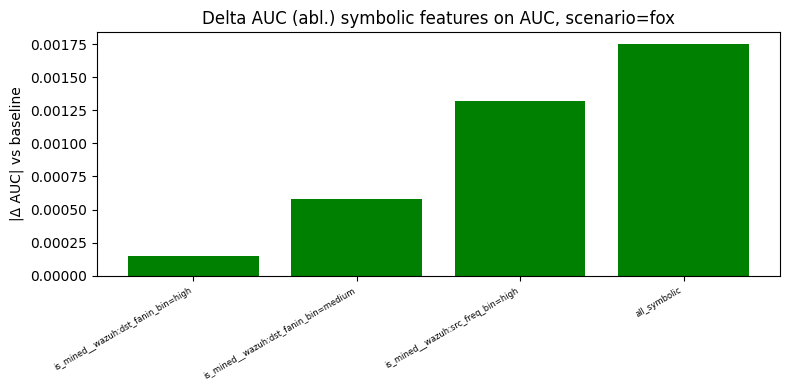

In [ ]:
diag_base = res["diag_base"]
diag_symbolic_all = res["diag_sym_all"]

print("\nBASE:", diag_base)
print("BASE+SYM:", diag_symbolic_all, "\n")

print("BASE FEATS: ", res["base_feats"])
print("SYM FEATS: ", res["sym_feats"])

results_dict = {"base": res["diag_base"]}
for feat, diag in res["diag_ablation"].items():
    results_dict[feat] = diag
results_dict["all_symbolic"] = res["diag_sym_all"]

plot_symbolic_performance_delta(
        results_dict,
        scenario_name=scenario_name,  
        metric="auc",
        out_dir=out_dir
)

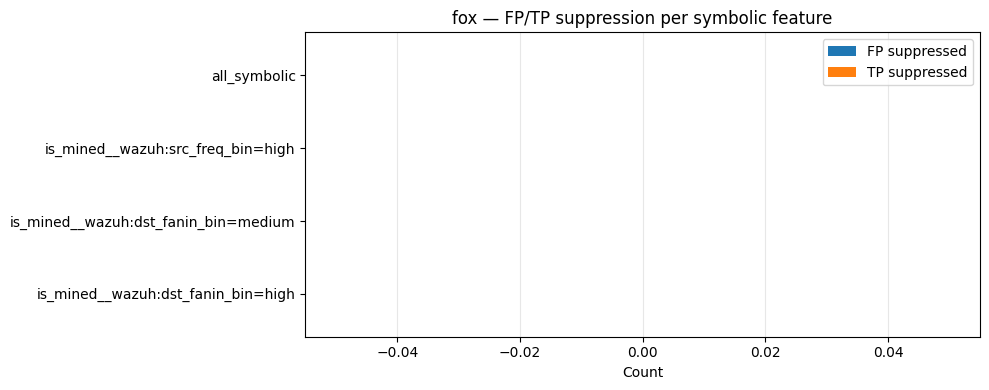

In [ ]:
df_plot = plot_suppression_from_res(
    res,
    scenario_name=scenario_name,
    fp_metric="suppressed_benign",
    tp_metric="suppressed_attack",
    out_dir=out_dir,
)